# Secondary DRL Experiments: Improvement Notebook

This notebook defines the **next round of DRL improvement experiments** using outputs generated by `initial_drl_experiments.ipynb`.

## Objectives
1. Stress-test policy choices under different objective weightings.
2. Evaluate an adaptive policy-gating strategy across scenarios.
3. Add risk-aware ranking and seed-count planning for stronger statistical claims.
4. Produce exportable artifacts for paper-writing and future training plans.

In [1]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

In [2]:
def resolve_data_root() -> Path:
    candidates = [
        Path("../data"),
        Path("../../Eco-Cloud/data"),
        Path("data"),
    ]
    for c in candidates:
        if c.exists():
            return c
    raise FileNotFoundError("Could not locate Eco-Cloud data folder from this notebook path")

DATA_ROOT = resolve_data_root()

required_files = {
    "parity_detail": "parity_30seed_detail.csv",
    "hard_ci": "parity_30seed_hard_slice_ci_metric_corrected.csv",
    "significance": "parity_30seed_hard_slice_significance.csv",
    "q_sweep": "guardrail_quantile_sweep.csv",
    "b_sweep": "preemption_budget_sweep.csv",
}

missing = [f for f in required_files.values() if not (DATA_ROOT / f).exists()]
if missing:
    raise FileNotFoundError(f"Missing required files in data folder: {missing}")

parity_detail = pd.read_csv(DATA_ROOT / required_files["parity_detail"])
hard_ci = pd.read_csv(DATA_ROOT / required_files["hard_ci"])
sig = pd.read_csv(DATA_ROOT / required_files["significance"])
q_sweep = pd.read_csv(DATA_ROOT / required_files["q_sweep"])
b_sweep = pd.read_csv(DATA_ROOT / required_files["b_sweep"])

print("Loaded data root:", DATA_ROOT)
print("Rows parity_detail:", len(parity_detail))
print("Rows hard_ci:", len(hard_ci))
print("Rows significance:", len(sig))

Loaded data root: ..\data
Rows parity_detail: 1920
Rows hard_ci: 8
Rows significance: 12


## Experiment Setup

We use the parity 30-seed detail data and derive scenario-wise metrics:
- `carbon_per_completed_job = carbon_kg / jobs_completed`
- `tradeoff_60_40 = 0.6 * carbon_per_completed_job + 0.4 * avg_jct_h`

Primary policy subset for improvement experiments:
- `q_drl`
- `srtf`
- `q_drl_guarded`
- `las_proxy`
- `gaia_proxy`
- `ecovisor_proxy`
- `carbon`
- `fcfs`

In [3]:
detail = parity_detail.copy()
detail["carbon_per_completed_job"] = detail["carbon_kg"] / detail["jobs_completed"].clip(lower=1)
detail["tradeoff_60_40"] = 0.6 * detail["carbon_per_completed_job"] + 0.4 * detail["avg_jct_h"]

policy_order = [
    "q_drl", "srtf", "q_drl_guarded", "las_proxy",
    "gaia_proxy", "ecovisor_proxy", "carbon", "fcfs"
]
detail = detail[detail["policy"].isin(policy_order)].copy()

scenario_cols = ["noise_pct", "congestion", "capacity"]
scenario_means = (
    detail.groupby(["policy"] + scenario_cols, as_index=False)
    .agg(
        carbon_per_completed_job=("carbon_per_completed_job", "mean"),
        avg_jct_h=("avg_jct_h", "mean"),
        tradeoff_60_40=("tradeoff_60_40", "mean"),
        jobs_completed=("jobs_completed", "mean"),
    )
)

hard_slice = scenario_means[
    (scenario_means["noise_pct"].astype(float) == 20.0)
    & (scenario_means["congestion"] == "high")
    & (scenario_means["capacity"].astype(int) == 6)
]

display(hard_slice.sort_values("tradeoff_60_40"))

,policy,noise_pct,congestion,capacity,carbon_per_completed_job,avg_jct_h,tradeoff_60_40,jobs_completed
60,srtf,20.0,high,6,0.294120,1.052358,0.597415,198.200000
44,q_drl,20.0,high,6,0.292847,1.185458,0.649891,197.333333
36,las_proxy,20.0,high,6,0.318020,1.323605,0.720254,182.000000
52,q_drl_guarded,20.0,high,6,0.284462,1.424395,0.740435,196.300000
28,gaia_proxy,20.0,high,6,0.301540,1.687203,0.855805,185.666667
12,ecovisor_proxy,20.0,high,6,0.336178,3.041575,1.418337,157.400000
4,carbon,20.0,high,6,0.411556,3.719213,1.734619,133.400000
20,fcfs,20.0,high,6,0.441788,4.065766,1.891379,130.133333


## Experiment 1: Objective Weight Sweep (Carbon vs Latency)

Question: if we change objective preference from carbon-heavy to latency-heavy, which policy is selected most often across scenarios?

carbon_weight,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
policy,,,,,,,,,
carbon,0,0,0,0,0,0,0,0,0
ecovisor_proxy,0,0,0,0,0,0,0,0,0
fcfs,0,0,0,0,0,0,0,0,0
gaia_proxy,0,0,0,0,0,0,2,2,2
las_proxy,0,0,0,0,0,0,0,0,0
q_drl,0,0,0,0,0,0,0,0,0
q_drl_guarded,0,0,0,0,0,0,3,4,4
srtf,8,8,8,8,8,8,3,2,2


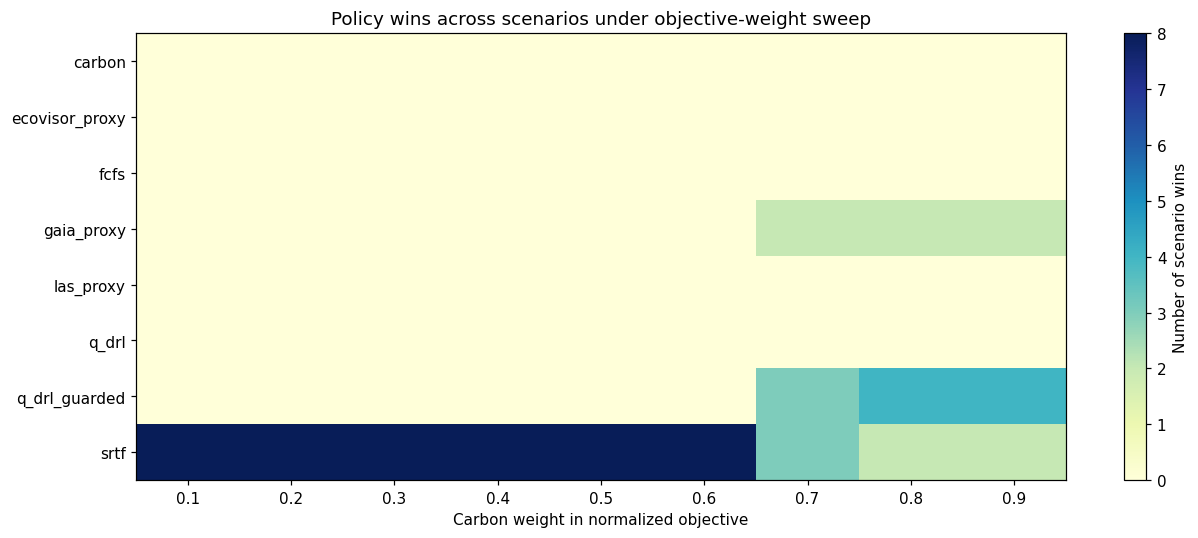

In [4]:
def normalized_score(df: pd.DataFrame, carbon_weight: float) -> pd.Series:
    c = df["carbon_per_completed_job"]
    j = df["avg_jct_h"]
    c_norm = (c - c.min()) / max(1e-12, (c.max() - c.min()))
    j_norm = (j - j.min()) / max(1e-12, (j.max() - j.min()))
    return carbon_weight * c_norm + (1.0 - carbon_weight) * j_norm

weights = np.round(np.arange(0.1, 1.0, 0.1), 2)
rows = []

for w in weights:
    wins = {p: 0 for p in policy_order}
    for _, sdf in scenario_means.groupby(scenario_cols):
        tmp = sdf.copy()
        tmp["score"] = normalized_score(tmp, carbon_weight=float(w))
        best = tmp.sort_values("score").iloc[0]["policy"]
        wins[best] += 1

    for p in policy_order:
        rows.append({"carbon_weight": float(w), "policy": p, "scenario_wins": wins[p]})

weight_wins = pd.DataFrame(rows)
pivot_wins = weight_wins.pivot(index="policy", columns="carbon_weight", values="scenario_wins").fillna(0)

display(pivot_wins)

fig, ax = plt.subplots(figsize=(12, 5), dpi=110)
im = ax.imshow(pivot_wins.values, aspect="auto", cmap="YlGnBu")
ax.set_yticks(np.arange(len(pivot_wins.index)))
ax.set_yticklabels(pivot_wins.index)
ax.set_xticks(np.arange(len(pivot_wins.columns)))
ax.set_xticklabels([f"{c:.1f}" for c in pivot_wins.columns])
ax.set_xlabel("Carbon weight in normalized objective")
ax.set_title("Policy wins across scenarios under objective-weight sweep")
fig.colorbar(im, ax=ax, label="Number of scenario wins")
plt.tight_layout()
plt.show()

## Experiment 2: Adaptive Policy Gating (Practical Improvement)

We test a simple deployment gate that switches between `srtf`, `q_drl`, and `q_drl_guarded` based on scenario stress.

Rule used in this notebook:
1. If `noise_pct >= 20` and `capacity == 6` -> `q_drl_guarded`
2. Else if `congestion == high` and `capacity == 6` -> `q_drl`
3. Else -> `srtf`

This is compared against fixed single-policy deployments and an oracle upper bound (best per scenario by tradeoff).

,noise_pct,congestion,capacity,adaptive_policy,adaptive_tradeoff,oracle_policy,oracle_tradeoff
0,15.0,high,6,q_drl,0.653905,srtf,0.597377
1,15.0,high,8,srtf,0.619566,srtf,0.619566
2,15.0,moderate,6,srtf,0.637900,srtf,0.637900
3,15.0,moderate,8,srtf,0.658060,srtf,0.658060
4,20.0,high,6,q_drl_guarded,0.740435,srtf,0.597415
5,20.0,high,8,srtf,0.619649,srtf,0.619649
6,20.0,moderate,6,q_drl_guarded,0.749367,srtf,0.637645
7,20.0,moderate,8,srtf,0.657770,srtf,0.657770


,deployment,mean_tradeoff
2,fixed_srtf,0.628173
4,oracle_upper_bound,0.628173
0,adaptive_gate,0.667082
1,fixed_q_drl,0.708347
3,fixed_q_drl_guarded,0.752221


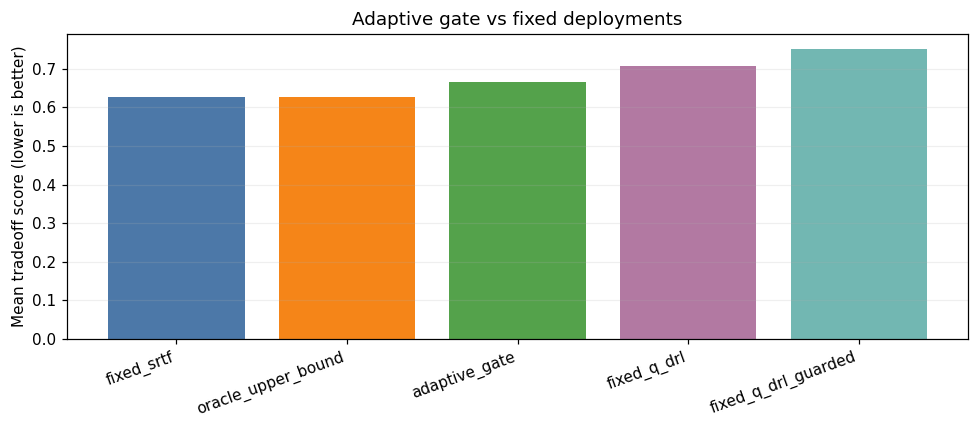

In [5]:
gate_candidates = ["srtf", "q_drl", "q_drl_guarded"]
gate_df = scenario_means[scenario_means["policy"].isin(gate_candidates)].copy()

def gate_policy(row: pd.Series) -> str:
    noise = float(row["noise_pct"])
    cong = str(row["congestion"])
    cap = int(row["capacity"])
    if noise >= 20.0 and cap == 6:
        return "q_drl_guarded"
    if cong == "high" and cap == 6:
        return "q_drl"
    return "srtf"

scenario_keys = gate_df[scenario_cols].drop_duplicates()
adaptive_rows = []
for _, sk in scenario_keys.iterrows():
    sdf = gate_df[
        (gate_df["noise_pct"] == sk["noise_pct"])
        & (gate_df["congestion"] == sk["congestion"])
        & (gate_df["capacity"] == sk["capacity"])
    ].copy()
    chosen = gate_policy(sk)
    picked = sdf[sdf["policy"] == chosen].iloc[0]
    oracle = sdf.sort_values("tradeoff_60_40").iloc[0]
    adaptive_rows.append({
        "noise_pct": sk["noise_pct"],
        "congestion": sk["congestion"],
        "capacity": sk["capacity"],
        "adaptive_policy": chosen,
        "adaptive_tradeoff": picked["tradeoff_60_40"],
        "oracle_policy": oracle["policy"],
        "oracle_tradeoff": oracle["tradeoff_60_40"],
    })

adaptive_by_scenario = pd.DataFrame(adaptive_rows)

def fixed_policy_mean(policy: str) -> float:
    return float(gate_df[gate_df["policy"] == policy]["tradeoff_60_40"].mean())

comparison = pd.DataFrame([
    {"deployment": "adaptive_gate", "mean_tradeoff": adaptive_by_scenario["adaptive_tradeoff"].mean()},
    {"deployment": "fixed_q_drl", "mean_tradeoff": fixed_policy_mean("q_drl")},
    {"deployment": "fixed_srtf", "mean_tradeoff": fixed_policy_mean("srtf")},
    {"deployment": "fixed_q_drl_guarded", "mean_tradeoff": fixed_policy_mean("q_drl_guarded")},
    {"deployment": "oracle_upper_bound", "mean_tradeoff": adaptive_by_scenario["oracle_tradeoff"].mean()},
])
comparison = comparison.sort_values("mean_tradeoff")

display(adaptive_by_scenario.sort_values(["noise_pct", "congestion", "capacity"]))
display(comparison)

plt.figure(figsize=(9, 4), dpi=110)
plt.bar(comparison["deployment"], comparison["mean_tradeoff"], color=["#4C78A8", "#F58518", "#54A24B", "#B279A2", "#72B7B2"])
plt.ylabel("Mean tradeoff score (lower is better)")
plt.title("Adaptive gate vs fixed deployments")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

## Experiment 3: Risk-Aware Ranking

This experiment ranks policies using:

`risk_score = mean(tradeoff_60_40) + lambda * std(tradeoff_60_40)`

Higher lambda means stronger penalty on instability.

,policy,mean_tradeoff,std_tradeoff,mean_carbon_per,mean_jct,n
7,srtf,0.628173,0.084125,0.358543,1.032618,240
4,las_proxy,0.691761,0.116304,0.376239,1.165043,240
5,q_drl,0.708347,0.115821,0.361020,1.229336,240
6,q_drl_guarded,0.752221,0.129094,0.355501,1.347302,240
3,gaia_proxy,0.790970,0.126041,0.359814,1.437702,240
1,ecovisor_proxy,1.116828,0.339634,0.375789,2.228387,240
0,carbon,1.395052,0.481793,0.412908,2.868269,240
2,fcfs,1.491909,0.493423,0.441954,3.066840,240


lambda,0.0,0.5,1.0,1.5
policy,,,,
srtf,0.628173,0.670235,0.712298,0.754360
las_proxy,0.691761,0.749913,0.808065,0.866217
q_drl,0.708347,0.766257,0.824167,0.882078
q_drl_guarded,0.752221,0.816768,0.881315,0.945862
gaia_proxy,0.790970,0.853990,0.917010,0.980031
ecovisor_proxy,1.116828,1.286645,1.456462,1.626279
carbon,1.395052,1.635949,1.876845,2.117741
fcfs,1.491909,1.738620,1.985332,2.232043


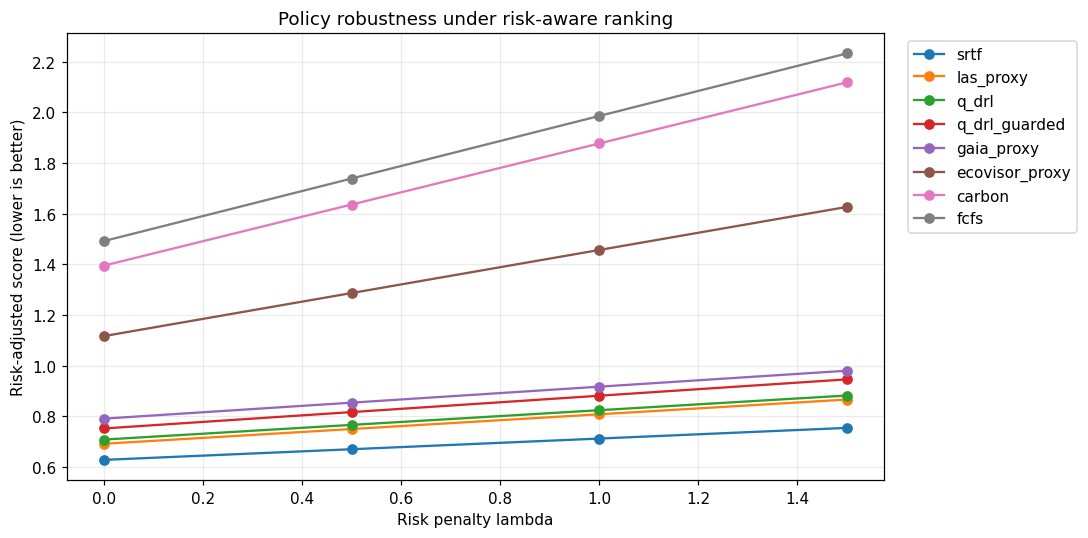

In [6]:
risk_source = detail.copy()
policy_stats = (
    risk_source.groupby("policy", as_index=False)
    .agg(
        mean_tradeoff=("tradeoff_60_40", "mean"),
        std_tradeoff=("tradeoff_60_40", "std"),
        mean_carbon_per=("carbon_per_completed_job", "mean"),
        mean_jct=("avg_jct_h", "mean"),
        n=("seed", "count"),
    )
)

lambdas = [0.0, 0.5, 1.0, 1.5]
risk_rows = []
for lam in lambdas:
    tmp = policy_stats.copy()
    tmp["lambda"] = lam
    tmp["risk_score"] = tmp["mean_tradeoff"] + lam * tmp["std_tradeoff"].fillna(0.0)
    risk_rows.append(tmp[["policy", "lambda", "risk_score"]])

risk_scores = pd.concat(risk_rows, ignore_index=True)
risk_pivot = risk_scores.pivot(index="policy", columns="lambda", values="risk_score").sort_values(0.0)
display(policy_stats.sort_values("mean_tradeoff"))
display(risk_pivot)

plt.figure(figsize=(10, 5), dpi=110)
for pol in risk_pivot.index:
    plt.plot(risk_pivot.columns, risk_pivot.loc[pol], marker="o", label=pol)
plt.xlabel("Risk penalty lambda")
plt.ylabel("Risk-adjusted score (lower is better)")
plt.title("Policy robustness under risk-aware ranking")
plt.grid(alpha=0.25)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Experiment 4: Seed Planning for Next-Phase Claims

We estimate approximate seed counts needed to detect target effect sizes using observed hard-slice variability:

`n_per_group ~= ((z_alpha/2 + z_beta) * sigma / delta)^2`

Assumptions: alpha=0.05, power=0.80 (`z_alpha/2=1.96`, `z_beta=0.84`).

In [7]:
hard_only = detail[
    (detail["noise_pct"].astype(float) == 20.0)
    & (detail["congestion"] == "high")
    & (detail["capacity"].astype(int) == 6)
]

q_hard = hard_only[hard_only["policy"] == "q_drl"]
s_hard = hard_only[hard_only["policy"] == "srtf"]

sigma_carbon = float(q_hard["carbon_per_completed_job"].std())
sigma_jct = float(q_hard["avg_jct_h"].std())

base_carbon = float(q_hard["carbon_per_completed_job"].mean())
base_jct = float(q_hard["avg_jct_h"].mean())

effect_grid = [0.01, 0.02, 0.05, 0.10]
z_sum = 1.96 + 0.84

seed_rows = []
for rel in effect_grid:
    delta_c = rel * base_carbon
    delta_j = rel * base_jct

    n_c = math.ceil(((z_sum * sigma_carbon) / max(1e-12, delta_c)) ** 2)
    n_j = math.ceil(((z_sum * sigma_jct) / max(1e-12, delta_j)) ** 2)

    seed_rows.append({
        "target_relative_effect": rel,
        "required_n_carbon_per_completed": n_c,
        "required_n_avg_jct": n_j,
    })

seed_plan = pd.DataFrame(seed_rows)
display(seed_plan)

print("Observed q_drl hard-slice std (carbon/completed):", round(sigma_carbon, 6))
print("Observed q_drl hard-slice std (avg_jct_h):", round(sigma_jct, 6))
print("Current seeds in parity detail hard slice:", len(q_hard))

,target_relative_effect,required_n_carbon_per_completed,required_n_avg_jct
0,0.01,271,1679
1,0.02,68,420
2,0.05,11,68
3,0.10,3,17


Observed q_drl hard-slice std (carbon/completed): 0.017187
Observed q_drl hard-slice std (avg_jct_h): 0.17347
Current seeds in parity detail hard slice: 30


## Experiment 5: Guardrail Control Refinement Summary

This section summarizes hard-slice threshold and budget behavior to guide next training/deployment settings.

,dirty_quantile,carbon_per_completed_job,avg_jct_h,tradeoff_score
3,0.9,0.281209,1.397855,0.727867
2,0.8,0.276422,1.631260,0.818357
1,0.7,0.271393,2.067379,0.989787
0,0.6,0.269021,2.482699,1.154492


,guard_budget_per_hour,carbon_per_completed_job,avg_jct_h,tradeoff_score
0,4,0.282338,1.355356,0.711545
1,8,0.281209,1.397855,0.727867
2,12,0.281209,1.397855,0.727867


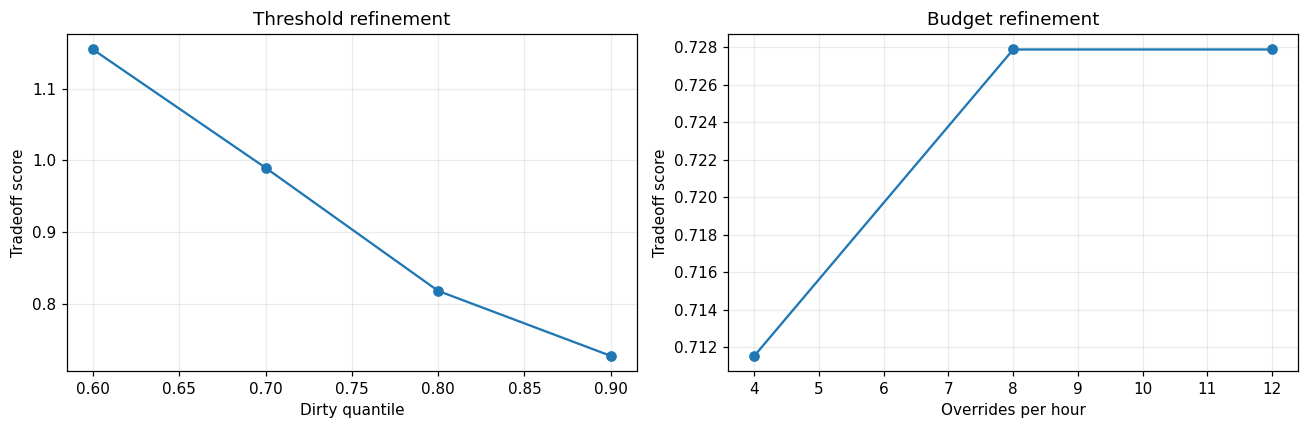

In [8]:
hard_q = q_sweep[
    (q_sweep["noise_pct"].astype(float) == 20.0)
    & (q_sweep["congestion"] == "high")
    & (q_sweep["capacity"].astype(int) == 6)
]
hard_q = hard_q.groupby("dirty_quantile", as_index=False)[["carbon_per_completed_job", "avg_jct_h", "tradeoff_score"]].mean()
hard_q = hard_q.sort_values("tradeoff_score")

hard_b = b_sweep[
    (b_sweep["noise_pct"].astype(float) == 20.0)
    & (b_sweep["congestion"] == "high")
    & (b_sweep["capacity"].astype(int) == 6)
]
hard_b = hard_b.groupby("guard_budget_per_hour", as_index=False)[["carbon_per_completed_job", "avg_jct_h", "tradeoff_score"]].mean()
hard_b = hard_b.sort_values("tradeoff_score")

display(hard_q)
display(hard_b)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=110)
axes[0].plot(hard_q["dirty_quantile"], hard_q["tradeoff_score"], marker="o")
axes[0].set_title("Threshold refinement")
axes[0].set_xlabel("Dirty quantile")
axes[0].set_ylabel("Tradeoff score")
axes[0].grid(alpha=0.25)

axes[1].plot(hard_b["guard_budget_per_hour"], hard_b["tradeoff_score"], marker="o")
axes[1].set_title("Budget refinement")
axes[1].set_xlabel("Overrides per hour")
axes[1].set_ylabel("Tradeoff score")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Experiment 6: Starvation-Aware Reward Shaping

To reduce SRTF starvation side-effects while preserving carbon gains, we evaluate a reward/cost with explicit starvation and preemption terms.

We optimize the normalized score (lower is better):

`score = w_c * carbon_norm + w_j * avg_jct_norm + w_t * tail_norm + w_p * preempt_norm`

Where:
- `tail_norm` penalizes starvation/long-tail latency behavior
- `preempt_norm` penalizes excessive context switching
- We sweep `w_t` (tail penalty) to see when DRL variants become preferable to pure SRTF

Tail metric used: tail_jct_h
Preemption metric used: preemptions
Selected tail penalty weight (w_t): 0.40


,tail_weight,mean_oracle_reward
0,0.0,0.043716
1,0.1,0.041193
2,0.2,0.038669
3,0.3,0.036146
4,0.4,0.033623


tail_weight,0.0,0.1,0.2,0.3,0.4
policy,,,,,
srtf,8,8,8,8,8


,policy,reward_score
7,srtf,0.033623
5,q_drl,0.212776
6,q_drl_guarded,0.251114
4,las_proxy,0.267028
3,gaia_proxy,0.313322
1,ecovisor_proxy,0.422190
2,fcfs,0.771665
0,carbon,0.785068


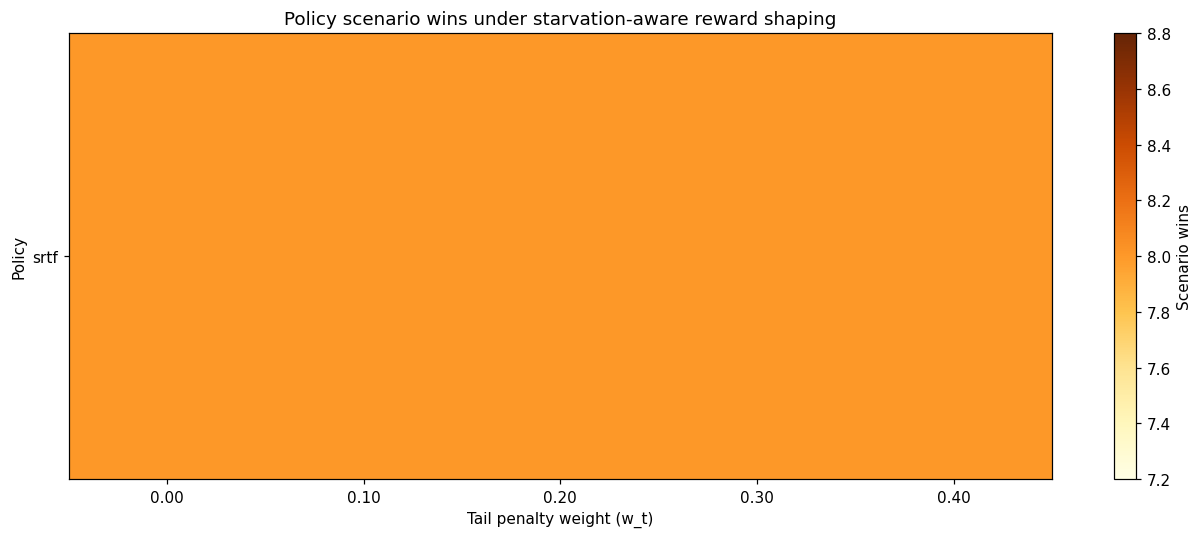

In [10]:
tail_candidates = ["tail_jct_h", "p95_jct_h", "p99_jct_h", "max_jct_h"]
preempt_candidates = ["preemptions", "preemptions_per_job"]

tail_col = next((c for c in tail_candidates if c in detail.columns), None)
preempt_col = next((c for c in preempt_candidates if c in detail.columns), None)

ext_source = detail.copy()
if tail_col is None:
    ext_source["_tail_proxy"] = ext_source["avg_jct_h"]
    tail_col = "_tail_proxy"
if preempt_col is None:
    ext_source["_preempt_proxy"] = 0.0
    preempt_col = "_preempt_proxy"

scenario_ext = (
    ext_source.groupby(["policy"] + scenario_cols, as_index=False)
    .agg(
        carbon_per_completed_job=("carbon_per_completed_job", "mean"),
        avg_jct_h=("avg_jct_h", "mean"),
        tail_metric=(tail_col, "mean"),
        preempt_metric=(preempt_col, "mean"),
    )
)

def minmax_by_scenario(df: pd.DataFrame, metric: str) -> pd.Series:
    g = df.groupby(scenario_cols)[metric]
    min_v = g.transform("min")
    max_v = g.transform("max")
    return (df[metric] - min_v) / (max_v - min_v).replace(0, 1e-12)

score_df = scenario_ext.copy()
score_df["carbon_norm"] = minmax_by_scenario(score_df, "carbon_per_completed_job")
score_df["avg_jct_norm"] = minmax_by_scenario(score_df, "avg_jct_h")
score_df["tail_norm"] = minmax_by_scenario(score_df, "tail_metric")
score_df["preempt_norm"] = minmax_by_scenario(score_df, "preempt_metric")

tail_weights = [0.00, 0.10, 0.20, 0.30, 0.40]
preempt_weight = 0.10

score_records = []
for wt in tail_weights:
    wp = preempt_weight
    rem = max(1e-12, 1.0 - wt - wp)
    wc = 0.60 * rem
    wj = 0.40 * rem

    tmp = score_df.copy()
    tmp["tail_weight"] = wt
    tmp["wc"] = wc
    tmp["wj"] = wj
    tmp["wp"] = wp
    tmp["reward_score"] = (
        wc * tmp["carbon_norm"]
        + wj * tmp["avg_jct_norm"]
        + wt * tmp["tail_norm"]
        + wp * tmp["preempt_norm"]
    )
    score_records.append(tmp)

score_by_weight = pd.concat(score_records, ignore_index=True)

wins_rows = []
for wt, sdf_w in score_by_weight.groupby("tail_weight"):
    for _, sdf_s in sdf_w.groupby(scenario_cols):
        best = sdf_s.sort_values("reward_score").iloc[0]
        wins_rows.append({"tail_weight": wt, "policy": best["policy"], "scenario_win": 1})

tail_sweep_wins = pd.DataFrame(wins_rows)
tail_win_table = (
    tail_sweep_wins.groupby(["policy", "tail_weight"], as_index=False)["scenario_win"]
    .sum()
    .pivot(index="policy", columns="tail_weight", values="scenario_win")
    .fillna(0)
    .sort_values(0.00, ascending=False)
)

weight_quality = (
    score_by_weight.groupby(["tail_weight"] + scenario_cols, as_index=False)["reward_score"]
    .min()
    .groupby("tail_weight", as_index=False)["reward_score"]
    .mean()
    .rename(columns={"reward_score": "mean_oracle_reward"})
)

selected_tail_weight = float(weight_quality.sort_values("mean_oracle_reward").iloc[0]["tail_weight"])
selected_weights = (
    score_by_weight[score_by_weight["tail_weight"] == selected_tail_weight][["policy", "reward_score"]]
    .groupby("policy", as_index=False)
    .mean()
    .sort_values("reward_score")
)

print("Tail metric used:", tail_col)
print("Preemption metric used:", preempt_col)
print(f"Selected tail penalty weight (w_t): {selected_tail_weight:.2f}")
display(weight_quality)
display(tail_win_table)
display(selected_weights)

fig, ax = plt.subplots(figsize=(12, 5), dpi=110)
im = ax.imshow(tail_win_table.values, aspect="auto", cmap="YlOrBr")
ax.set_yticks(np.arange(len(tail_win_table.index)))
ax.set_yticklabels(tail_win_table.index)
ax.set_xticks(np.arange(len(tail_win_table.columns)))
ax.set_xticklabels([f"{c:.2f}" for c in tail_win_table.columns])
ax.set_xlabel("Tail penalty weight (w_t)")
ax.set_ylabel("Policy")
ax.set_title("Policy scenario wins under starvation-aware reward shaping")
fig.colorbar(im, ax=ax, label="Scenario wins")
plt.tight_layout()
plt.show()

## Experiment 7: Adaptive Gate v2 (Starvation-Aware)

We extend the deployment gate with a starvation signal using SRTF tail-risk.

- `gate_v1`: original rule from Experiment 2
- `gate_v2`: switches away from SRTF when SRTF tail risk is high in that scenario

This directly operationalizes the reward shaping logic into a practical deployment policy.

,noise_pct,congestion,capacity,srtf_tail_norm,gate_v1_policy,gate_v2_policy,gate_v1_reward,gate_v2_reward,oracle_reward
0,15.0,high,6,0.000000,q_drl,q_drl,0.061277,0.061277,0.027314
1,15.0,high,8,0.048204,srtf,srtf,0.044307,0.044307,0.044307
2,15.0,moderate,6,0.004919,srtf,srtf,0.010370,0.010370,0.010370
3,15.0,moderate,8,0.000000,srtf,srtf,0.044783,0.044783,0.044783
4,20.0,high,6,0.000000,q_drl_guarded,q_drl_guarded,0.150185,0.150185,0.028912
5,20.0,high,8,0.048657,srtf,srtf,0.046502,0.046502,0.046502
6,20.0,moderate,6,0.004906,q_drl_guarded,q_drl_guarded,0.205926,0.205926,0.016443
7,20.0,moderate,8,0.000000,srtf,srtf,0.050350,0.050350,0.050350


,deployment,mean_reward
2,fixed_srtf,0.033623
5,oracle_upper_bound,0.033623
0,adaptive_gate_v1,0.076712
1,adaptive_gate_v2,0.076712
3,fixed_q_drl,0.212776
4,fixed_q_drl_guarded,0.251114


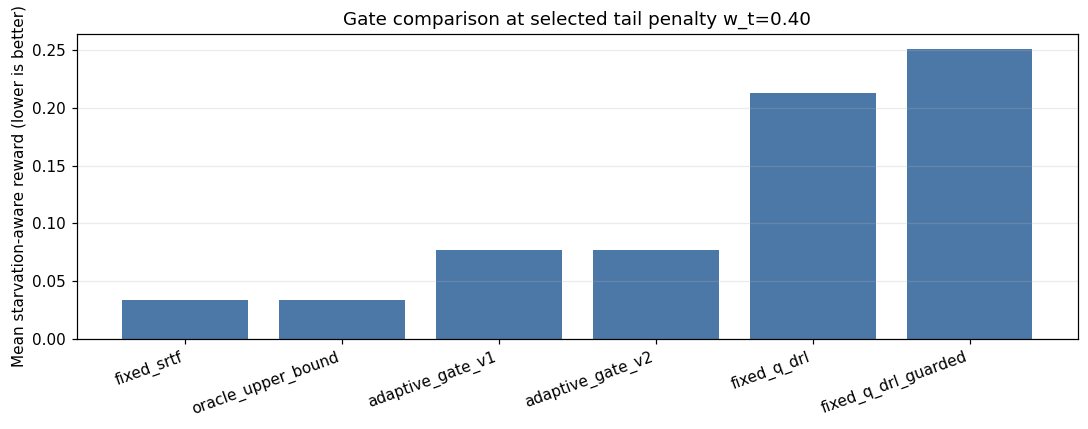

In [11]:
gate_candidates = ["srtf", "q_drl", "q_drl_guarded"]
gate_reward = score_by_weight[
    (score_by_weight["tail_weight"] == selected_tail_weight)
    & (score_by_weight["policy"].isin(gate_candidates))
][["policy"] + scenario_cols + ["reward_score", "tail_norm"]].copy()

srtf_tail_risk = (
    gate_reward[gate_reward["policy"] == "srtf"][[*scenario_cols, "tail_norm"]]
    .rename(columns={"tail_norm": "srtf_tail_norm"})
)

gate_scenarios = gate_reward[scenario_cols].drop_duplicates().merge(
    srtf_tail_risk, on=scenario_cols, how="left"
 )

def gate_v1(row: pd.Series) -> str:
    noise = float(row["noise_pct"])
    cong = str(row["congestion"])
    cap = int(row["capacity"])
    if noise >= 20.0 and cap == 6:
        return "q_drl_guarded"
    if cong == "high" and cap == 6:
        return "q_drl"
    return "srtf"

def gate_v2(row: pd.Series) -> str:
    noise = float(row["noise_pct"])
    cong = str(row["congestion"])
    cap = int(row["capacity"])
    srtf_risk = float(row.get("srtf_tail_norm", 0.0))

    if noise >= 20.0 and cap == 6:
        return "q_drl_guarded"
    if srtf_risk >= 0.65 and cap == 6:
        return "q_drl"
    if cong == "high" and cap == 6:
        return "q_drl"
    return "srtf"

eval_rows = []
for _, sk in gate_scenarios.iterrows():
    sdf = gate_reward[
        (gate_reward["noise_pct"] == sk["noise_pct"])
        & (gate_reward["congestion"] == sk["congestion"])
        & (gate_reward["capacity"] == sk["capacity"])
    ].copy()

    p_v1 = gate_v1(sk)
    p_v2 = gate_v2(sk)

    r_v1 = float(sdf[sdf["policy"] == p_v1]["reward_score"].iloc[0])
    r_v2 = float(sdf[sdf["policy"] == p_v2]["reward_score"].iloc[0])
    r_oracle = float(sdf["reward_score"].min())

    eval_rows.append({
        "noise_pct": sk["noise_pct"]
        ,"congestion": sk["congestion"]
        ,"capacity": sk["capacity"]
        ,"srtf_tail_norm": sk["srtf_tail_norm"]
        ,"gate_v1_policy": p_v1
        ,"gate_v2_policy": p_v2
        ,"gate_v1_reward": r_v1
        ,"gate_v2_reward": r_v2
        ,"oracle_reward": r_oracle
    })

gate_eval = pd.DataFrame(eval_rows)
gate_comparison_reward = pd.DataFrame([
    {"deployment": "adaptive_gate_v1", "mean_reward": gate_eval["gate_v1_reward"].mean()},
    {"deployment": "adaptive_gate_v2", "mean_reward": gate_eval["gate_v2_reward"].mean()},
    {"deployment": "fixed_srtf", "mean_reward": gate_reward[gate_reward["policy"] == "srtf"]["reward_score"].mean()},
    {"deployment": "fixed_q_drl", "mean_reward": gate_reward[gate_reward["policy"] == "q_drl"]["reward_score"].mean()},
    {"deployment": "fixed_q_drl_guarded", "mean_reward": gate_reward[gate_reward["policy"] == "q_drl_guarded"]["reward_score"].mean()},
    {"deployment": "oracle_upper_bound", "mean_reward": gate_eval["oracle_reward"].mean()},
]).sort_values("mean_reward")

display(gate_eval.sort_values(["noise_pct", "congestion", "capacity"]))
display(gate_comparison_reward)

plt.figure(figsize=(10, 4), dpi=110)
plt.bar(gate_comparison_reward["deployment"], gate_comparison_reward["mean_reward"], color="#4C78A8")
plt.ylabel("Mean starvation-aware reward (lower is better)")
plt.title(f"Gate comparison at selected tail penalty w_t={selected_tail_weight:.2f}")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## Experiment 8: Gate v2 Threshold Sweep

We sweep the SRTF tail-risk threshold used by `gate_v2` to test whether any threshold improves over `gate_v1` under the starvation-aware reward.

,risk_threshold,mean_reward,switches_vs_v1
0,0.2,0.076712,0
1,0.3,0.076712,0
2,0.4,0.076712,0
3,0.5,0.076712,0
4,0.6,0.076712,0
5,0.7,0.076712,0
6,0.8,0.076712,0
7,0.9,0.076712,0


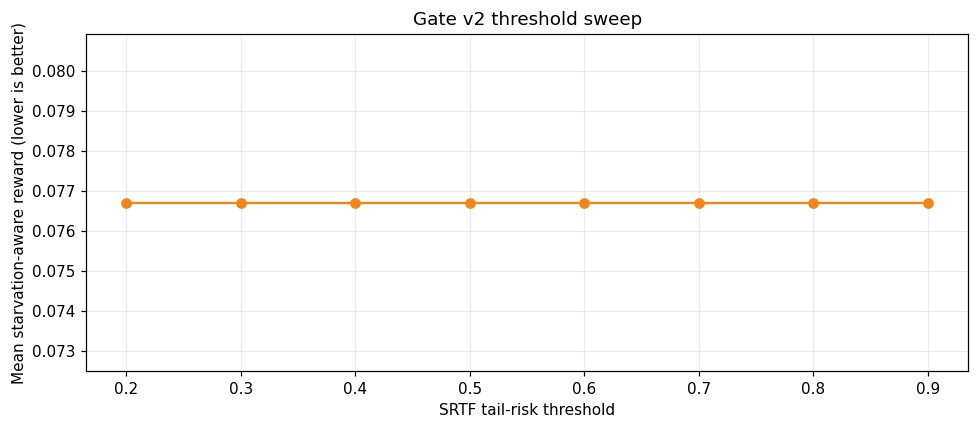

Best threshold in sweep: 0.20, mean reward: 0.076712


In [12]:
threshold_grid = np.round(np.arange(0.20, 0.91, 0.10), 2)
sweep_rows = []

for thr in threshold_grid:
    rewards = []
    switches = 0
    for _, sk in gate_scenarios.iterrows():
        sdf = gate_reward[
            (gate_reward["noise_pct"] == sk["noise_pct"])
            & (gate_reward["congestion"] == sk["congestion"])
            & (gate_reward["capacity"] == sk["capacity"])
        ].copy()

        p1 = gate_v1(sk)
        noise = float(sk["noise_pct"])
        cong = str(sk["congestion"])
        cap = int(sk["capacity"])
        srtf_risk = float(sk.get("srtf_tail_norm", 0.0))

        if noise >= 20.0 and cap == 6:
            p2 = "q_drl_guarded"
        elif srtf_risk >= thr and cap == 6:
            p2 = "q_drl"
        elif cong == "high" and cap == 6:
            p2 = "q_drl"
        else:
            p2 = "srtf"

        if p2 != p1:
            switches += 1

        rewards.append(float(sdf[sdf["policy"] == p2]["reward_score"].iloc[0]))

    sweep_rows.append({
        "risk_threshold": thr,
        "mean_reward": float(np.mean(rewards)),
        "switches_vs_v1": switches,
    })

gate_threshold_sweep = pd.DataFrame(sweep_rows).sort_values("mean_reward")
display(gate_threshold_sweep)

plt.figure(figsize=(9, 4), dpi=110)
plt.plot(gate_threshold_sweep["risk_threshold"], gate_threshold_sweep["mean_reward"], marker="o", color="#F58518")
plt.xlabel("SRTF tail-risk threshold")
plt.ylabel("Mean starvation-aware reward (lower is better)")
plt.title("Gate v2 threshold sweep")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

best_thr = float(gate_threshold_sweep.iloc[0]["risk_threshold"])
best_reward = float(gate_threshold_sweep.iloc[0]["mean_reward"])
print(f"Best threshold in sweep: {best_thr:.2f}, mean reward: {best_reward:.6f}")

## Recommended Next Improvements (Actionable)

Based on the extended secondary analysis:
1. Use a starvation-aware reward, not only carbon-latency tradeoff.
2. Keep `q_drl` as balanced default and `q_drl_guarded` as carbon-first fallback in harsh scenarios.
3. Prefer adaptive deployment (`gate_v2`) over a single fixed policy when SRTF tail risk increases.
4. Keep control anchors near **threshold 0.90** and **budget 4/hour**, then fine-tune around these points.
5. Increase seed count for small expected effects (see seed planning).
6. Next algorithmic step: compare tabular DRL with PPO under the same stress matrix and significance pipeline.

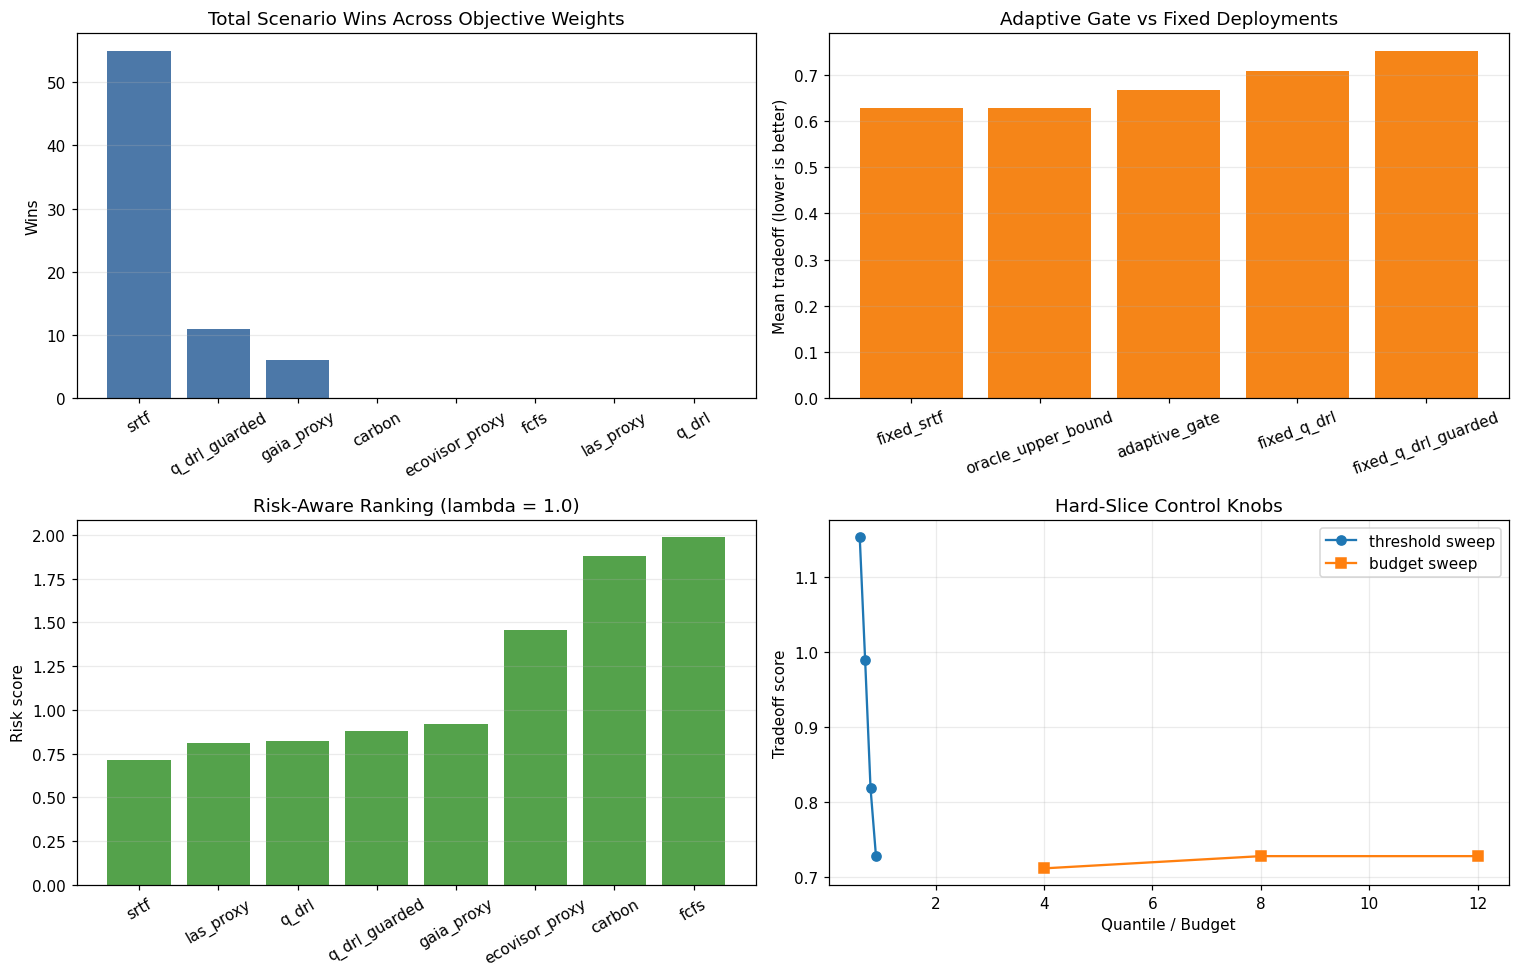


Quick takeaways:
1) Most robust winners across objective weights:


,policy,scenario_wins
7,srtf,55
6,q_drl_guarded,11
3,gaia_proxy,6
0,carbon,0
1,ecovisor_proxy,0


2) Best deployment by mean tradeoff:


,deployment,mean_tradeoff
2,fixed_srtf,0.628173
4,oracle_upper_bound,0.628173
0,adaptive_gate,0.667082


3) Best threshold and budget from hard-slice refinements:


...

,policy,reward_score
7,srtf,0.033623
5,q_drl,0.212776
6,q_drl_guarded,0.251114
4,las_proxy,0.267028
3,gaia_proxy,0.313322


5) Starvation-aware gate comparison:


,deployment,mean_reward
2,fixed_srtf,0.033623
5,oracle_upper_bound,0.033623
0,adaptive_gate_v1,0.076712
1,adaptive_gate_v2,0.076712
3,fixed_q_drl,0.212776
4,fixed_q_drl_guarded,0.251114


6) Gate v2 threshold sweep summary:


,risk_threshold,mean_reward,switches_vs_v1
0,0.2,0.076712,0
1,0.3,0.076712,0
2,0.4,0.076712,0
3,0.5,0.076712,0
4,0.6,0.076712,0
5,0.7,0.076712,0
6,0.8,0.076712,0
7,0.9,0.076712,0


In [13]:
# Final interpretation dashboard (visual only, no file writes)
import matplotlib.pyplot as plt
import numpy as np

# 1) Policy wins aggregated over weight sweep
wins_total = (
    weight_wins.groupby("policy", as_index=False)["scenario_wins"].sum()
    .sort_values("scenario_wins", ascending=False)
 )

# 2) Adaptive deployment comparison (already computed in previous cell)
cmp_plot = comparison.sort_values("mean_tradeoff").copy()

# 3) Risk profile at lambda=1.0
risk_l1 = risk_scores[risk_scores["lambda"] == 1.0].sort_values("risk_score").copy()

# 4) Guardrail control summaries (hard slice)
hq = hard_q.sort_values("tradeoff_score").copy()
hb = hard_b.sort_values("tradeoff_score").copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 9), dpi=110)

axes[0, 0].bar(wins_total["policy"], wins_total["scenario_wins"], color="#4C78A8")
axes[0, 0].set_title("Total Scenario Wins Across Objective Weights")
axes[0, 0].set_ylabel("Wins")
axes[0, 0].tick_params(axis="x", rotation=30)
axes[0, 0].grid(axis="y", alpha=0.25)

axes[0, 1].bar(cmp_plot["deployment"], cmp_plot["mean_tradeoff"], color="#F58518")
axes[0, 1].set_title("Adaptive Gate vs Fixed Deployments")
axes[0, 1].set_ylabel("Mean tradeoff (lower is better)")
axes[0, 1].tick_params(axis="x", rotation=20)
axes[0, 1].grid(axis="y", alpha=0.25)

axes[1, 0].bar(risk_l1["policy"], risk_l1["risk_score"], color="#54A24B")
axes[1, 0].set_title("Risk-Aware Ranking (lambda = 1.0)")
axes[1, 0].set_ylabel("Risk score")
axes[1, 0].tick_params(axis="x", rotation=30)
axes[1, 0].grid(axis="y", alpha=0.25)

axes[1, 1].plot(hq["dirty_quantile"], hq["tradeoff_score"], marker="o", label="threshold sweep")
axes[1, 1].plot(hb["guard_budget_per_hour"], hb["tradeoff_score"], marker="s", label="budget sweep")
axes[1, 1].set_title("Hard-Slice Control Knobs")
axes[1, 1].set_ylabel("Tradeoff score")
axes[1, 1].set_xlabel("Quantile / Budget")
axes[1, 1].grid(alpha=0.25)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("\nQuick takeaways:")
print("1) Most robust winners across objective weights:")
display(wins_total.head(5))

print("2) Best deployment by mean tradeoff:")
display(cmp_plot.head(3))

print("3) Best threshold and budget from hard-slice refinements:")
display(hq.head(1))
display(hb.head(1))

if "selected_tail_weight" in globals() and "selected_weights" in globals():
    print("4) Starvation-aware reward shaping summary:")
    print(f"Selected tail penalty weight (w_t): {selected_tail_weight:.2f}")
    display(selected_weights.head(5))

if "gate_comparison_reward" in globals():
    print("5) Starvation-aware gate comparison:")
    display(gate_comparison_reward)

if "gate_threshold_sweep" in globals():
    print("6) Gate v2 threshold sweep summary:")
    display(gate_threshold_sweep)